{'weight_kg': 77, 'height_mtrs': 1.67, 'category': 'Overweight', 'bmi': 27.61}


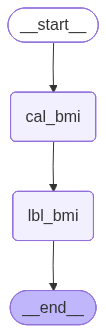

In [17]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image

#define state

class BMIState(TypedDict):
    weight_kg: float
    height_mtrs: float
    category: str
    bmi: float

def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_mtrs']

    bmi = weight / (height**2)
    state['bmi'] = round(bmi,2)

    return state

def lebel_bmi(state: BMIState)->BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state['category'] = 'UnderWeight'
    elif  18.5 <= bmi < 25:
        state['category'] = 'Normal'

    elif  25 <= bmi < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obese'

    return state

#define Graph
graph = StateGraph(BMIState)

#add nodes to the graph
graph.add_node('cal_bmi',calculate_bmi)
graph.add_node('lbl_bmi', lebel_bmi)

#add edges to the graph
graph.add_edge(START, 'cal_bmi')
graph.add_edge('cal_bmi', 'lbl_bmi')
graph.add_edge('lbl_bmi', END)

#compile the graph
workflow = graph.compile()

#execute the graph
initial_state = {'weight_kg':77, 'height_mtrs':1.67}
final_state = workflow.invoke(initial_state)
print(final_state)

#To see the graph 
Image(workflow.get_graph().draw_mermaid_png())